# 서비스 기획 3W - 카페 매장 지역별 맞춤 전략 분석
#### 1. Why
- 뉴욕 3개 카페 매장(Lower Manhattan, Hell's Kitchen, Astoria)이 동일한 메뉴/가격 정책으로 운영되고 있는데,
  지역별 상권 특성(오피스가 vs 주거지역 등)에 따라 실제 소비 패턴은 다를 수 있음
- 데이터 분석을 통해 지역별 차이를 검증하고, 매장별 맞춤 운영 전략이 필요한지 판단
#### 2. Who
- 3개 매장을 총괄하는 카페 체인 운영 매니저 / 지점 점장
#### 3. What
- 지역별 매출 패턴(카테고리 구성, 시간대, 객단가)을 비교 분석하여
  획일적 운영이 아닌 **지역 맞춤형 운영 전략(메뉴 구성, 영업시간, 인력배치)**을 도출


### 데이터 불러오기

In [30]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

In [31]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
data = pd.read_excel('./data/Coffee Shop Sales.xlsx', sheet_name='Transactions')

data

,거래번호,거래날짜,거래시간,거래수량,카페일련번호,카페지역,상품번호,제품가격,카테고리,제품명,제품설명
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


In [33]:
# 데이터 기본 정보 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   거래번호    149116 non-null  int64         
 1   거래날짜    149116 non-null  datetime64[ns]
 2   거래시간    149116 non-null  object        
 3   거래수량    149116 non-null  int64         
 4   카페일련번호  149116 non-null  int64         
 5   카페지역    149116 non-null  object        
 6   상품번호    149116 non-null  int64         
 7   제품가격    149116 non-null  float64       
 8   카테고리    149116 non-null  object        
 9   제품명     149116 non-null  object        
 10  제품설명    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [34]:
# 결측치 확인
data.isnull().sum()

거래번호      0
거래날짜      0
거래시간      0
거래수량      0
카페일련번호    0
카페지역      0
상품번호      0
제품가격      0
카테고리      0
제품명       0
제품설명      0
dtype: int64

In [35]:
# 거래번호를 인덱스로 설정
data.set_index('거래번호', inplace=True)

data.head()

,거래날짜,거래시간,거래수량,카페일련번호,카페지역,상품번호,제품가격,카테고리,제품명,제품설명
거래번호,,,,,,,,,,
1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


### [결측치 및 이상치 처리]
- 결측치는 확인 결과 존재하지 않음
- 제품가격(연속형 변수)에 대해서만 이상치 여부 확인

In [36]:
# 제품가격 이상치 확인 (IQR 방식)
Q1 = data['제품가격'].quantile(0.25)
Q3 = data['제품가격'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_cnt = len(data.loc[(data['제품가격'] < lower) | (data['제품가격'] > upper)])
print(f'이상치 개수: {outlier_cnt}건 / 전체 {len(data)}건')
# -> 프리미엄 원두, 브랜드 상품 등 고가 상품이 정상적으로 존재하는 것이므로
#    수치상 이상치이지만 실제 데이터 오류는 아님. 별도 제거하지 않고 그대로 사용

이상치 개수: 4212건 / 전체 149116건


### 데이터 연산 (파생변수 생성)
- 분석에 필요한 매출, 시간대, 요일, 평일/주말 컬럼을 새로 생성

In [37]:
# 매출 = 거래수량 * 제품가격
data['매출'] = data['거래수량'] * data['제품가격']

# 거래시간에서 시간대(hour)만 추출
data['시간대'] = pd.to_datetime(data['거래시간'], format='%H:%M:%S').dt.hour

# 거래날짜에서 요일 추출
data['요일'] = data['거래날짜'].dt.day_name()

# 평일/주말 구분
data['평일주말'] = data['요일'].isin(['Saturday', 'Sunday']).map({True: '주말', False: '평일'})

data[['거래날짜', '거래시간', '시간대', '요일', '평일주말', '거래수량', '제품가격', '매출']].head()

,거래날짜,거래시간,시간대,요일,평일주말,거래수량,제품가격,매출
거래번호,,,,,,,,
1,2023-01-01,07:06:11,7,Sunday,주말,2,3.0,6.0
2,2023-01-01,07:08:56,7,Sunday,주말,2,3.1,6.2
3,2023-01-01,07:14:04,7,Sunday,주말,2,4.5,9.0
4,2023-01-01,07:20:24,7,Sunday,주말,1,2.0,2.0
5,2023-01-01,07:22:41,7,Sunday,주말,2,3.1,6.2


# 1. 시나리오 (문제 배경 및 분석 목적)
> 카페 체인은 Lower Manhattan, Hell's Kitchen, Astoria 3개 지역에서 매장을 운영 중이며,
> 현재는 **모든 매장이 동일한 메뉴 구성, 가격 정책, 영업시간**으로 운영되고 있다.
>
> 하지만 세 지역은 상권 성격이 다르다. Lower Manhattan은 대표적인 **오피스 밀집 지역**이고,
> Astoria는 **주거 밀집 지역**에 가깝다. 상권이 다르면 고객의 방문 시간대, 선호 메뉴,
> 소비 금액도 다를 가능성이 높다.
>
> 이에 따라 매장(지역)별 실제 판매 데이터를 분석하여 **지역별 소비 패턴 차이를 검증**하고,
> 차이가 확인되는 영역에 한해 **지역 맞춤형 운영 전략(메뉴 구성, 영업시간, 인력배치)**을 제시하고자 한다.
> 아울러 6개월간 데이터에 나타난 **전체 매출 성장 추세의 원인**도 함께 분석한다.

# 2. 가설설정
> 1. 지역마다 잘 팔리는 상품 카테고리 구성비가 다를 것이다.
> 2. 지역마다 고객이 몰리는 시간대(피크타임) 패턴이 다를 것이다.
> 3. 지역마다 객단가(거래당 평균 구매금액)에 차이가 있을 것이다.
> 4. 6개월간의 매출 성장은 객단가 상승이 아닌 방문객수(트래픽) 증가에 기인하며, 이 성장 속도는 지역과 무관하게 동일할 것이다.


# 3. 가설검증

## 1) 지역마다 잘 팔리는 상품 카테고리 구성비가 다를 것이다.

In [38]:
# 지역, 카테고리 기준 매출 합계
# groupby로 지역-카테고리별 매출을 구한 뒤, pivot 형태로 변환
region_cat = data.groupby(['카페지역', '카테고리'])['매출'].sum().unstack()

# 지역 내 카테고리 비중(%)으로 정규화 -> 지역별 매출 규모 차이를 제거하고 '구성비'만 비교
region_cat_pct = region_cat.div(region_cat.sum(axis=1), axis=0) * 100
region_cat_pct.round(1)

카테고리,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
카페지역,,,,,,,,,
Astoria,11.5,2.3,38.6,4.4,11.3,0.8,1.4,0.5,29.2
Hell's Kitchen,11.6,0.8,38.6,7.9,10.0,1.2,1.9,0.7,27.4
Lower Manhattan,12.3,2.7,38.7,4.9,9.8,1.6,1.5,0.7,27.8


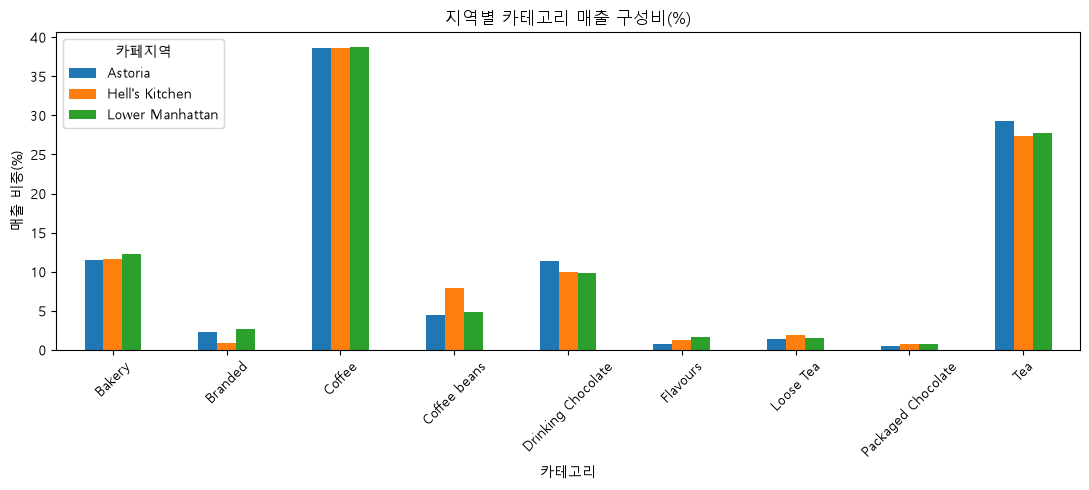

In [39]:
# 지역별 카테고리 구성비 시각화
region_cat_pct.T.plot(kind='bar', figsize=(11, 5))
plt.title('지역별 카테고리 매출 구성비(%)')
plt.ylabel('매출 비중(%)')
plt.xlabel('카테고리')
plt.xticks(rotation=45)
plt.legend(title='카페지역')
plt.tight_layout()
plt.show()

## 카테고리 구성비 분석 결과
> ### 분석 결과
> - Coffee(약 38~39%), Tea(약 27~29%) 비중이 세 지역 모두 거의 동일하게 1, 2위를 차지
> - Bakery, Drinking Chocolate 등 나머지 카테고리 비중도 지역 간 차이가 1~2%p 수준에 불과
> - **가설 1은 기각** : 상품 카테고리 구성비는 지역과 무관하게 매우 유사함 → 메뉴 포트폴리오 자체는 지역별로 다르게 가져갈 필요가 없어 보임


## 2) 지역마다 고객이 몰리는 시간대(피크타임) 패턴이 다를 것이다.

In [40]:
# 지역별 영업시간 범위 확인
data.groupby('카페지역')['시간대'].agg(['min', 'max'])

,min,max
카페지역,,
Astoria,7,19
Hell's Kitchen,6,20
Lower Manhattan,6,20


In [41]:
# 지역, 시간대 기준 매출 합계 후 지역 내 비중(%)으로 정규화
region_time = data.groupby(['카페지역', '시간대'])['매출'].sum().unstack()
region_time_pct = region_time.div(region_time.sum(axis=1), axis=0) * 100
region_time_pct.T.round(1)

카페지역,Astoria,Hell's Kitchen,Lower Manhattan
시간대,,,
6,NaN,3.2,6.2
7,8.2,6.7,12.4
8,9.8,13.3,12.3
9,10.0,13.9,12.7
10,10.5,14.2,13.3
11,6.7,7.6,5.6
12,6.8,4.8,5.7
13,6.9,5.1,5.4
14,6.5,5.2,6.0


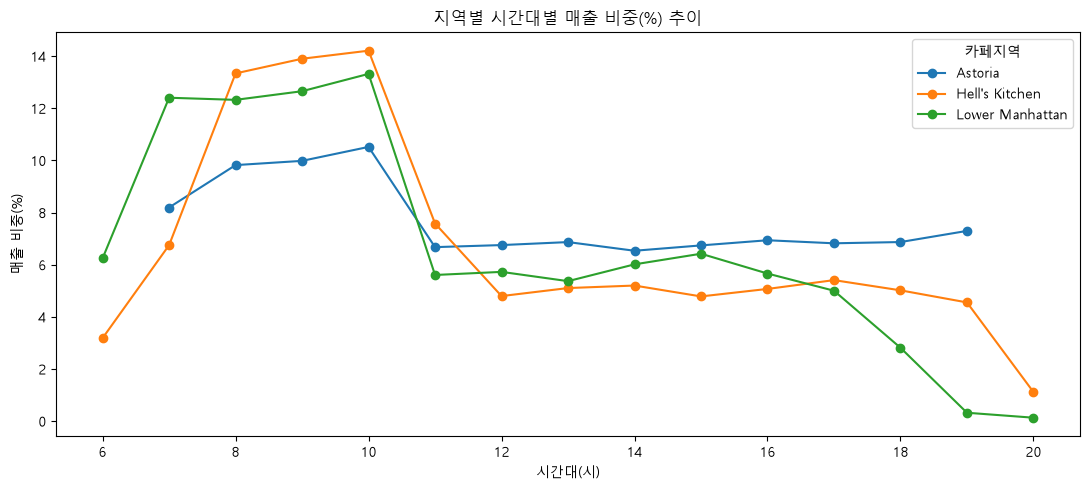

In [42]:
# 지역별 시간대 매출 비중 추이 시각화 (lineplot)
plt.figure(figsize=(11, 5))
for region in region_time_pct.index:
    plt.plot(region_time_pct.columns, region_time_pct.loc[region], marker='o', label=region)

plt.title('지역별 시간대별 매출 비중(%) 추이')
plt.xlabel('시간대(시)')
plt.ylabel('매출 비중(%)')
plt.legend(title='카페지역')
plt.tight_layout()
plt.show()

## 피크타임 분석 결과
> ### 분석 결과
> - 세 지역 모두 오전 8~10시가 매출 최고 시간대라는 점은 동일 (출근길 커피 수요는 공통적)
> - 하지만 **저녁 시간대 패턴은 뚜렷하게 다름**
>   - Lower Manhattan: 18시 이후 매출 비중이 2.8% → 19시 0.3% → 20시 0.1%로 급격히 감소, 사실상 저녁 영업이 의미가 없음
>   - Astoria: 18시 6.9%, 19시 7.3%로 오전 피크타임과 큰 차이 없이 저녁까지 꾸준히 매출 발생, 영업시간도 7~19시로 더 늦게 열고 늦게 닫음
>   - Hell's Kitchen: 두 지역의 중간 정도의 완만한 감소 패턴
> - **가설 2는 채택** : Lower Manhattan은 전형적인 '오피스 상권형(출퇴근 집중)', Astoria는 '주거 상권형(하루 종일 분산)' 패턴을 보임


## 3) 지역마다 객단가(거래당 평균 구매금액)에 차이가 있을 것이다.

In [43]:
# 거래(주문) 단위로 매출 합산 -> 객단가 계산
# 원본 data는 한 거래번호(인덱스) 안에 여러 상품 행이 섞여있을 수 있으므로 reset_index 후 재집계
trans = data.reset_index().groupby(['거래번호', '카페지역'])['매출'].sum().reset_index()

trans.groupby('카페지역')['매출'].agg(['mean', 'median', 'std']).round(2)

,mean,median,std
카페지역,,,
Astoria,4.59,3.75,2.88
Hell's Kitchen,4.66,3.75,5.84
Lower Manhattan,4.81,3.75,3.28


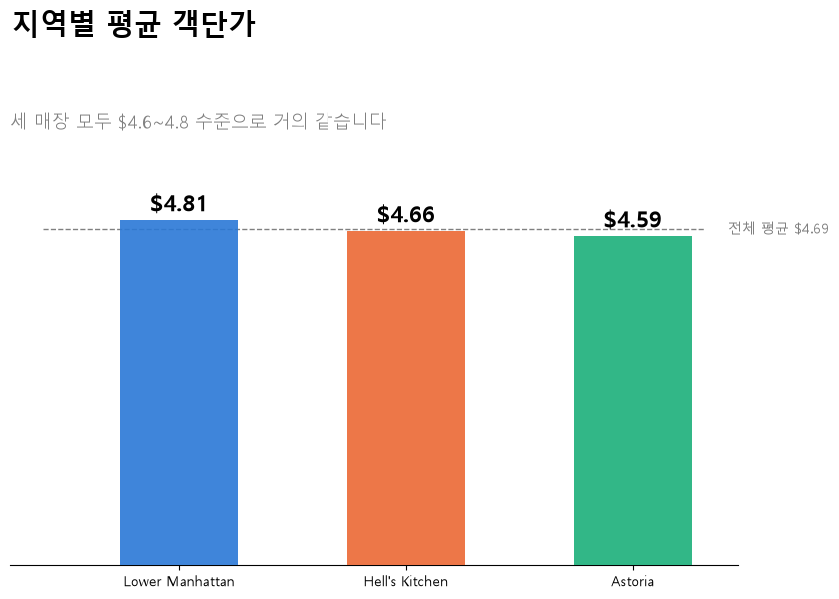

In [44]:
# 지역별 평균 객단가 막대그래프
means = trans.groupby('카페지역')['매출'].mean().sort_values(ascending=False)
colors = ['#2a78d6', '#eb6834', '#1baf7a']

fig, ax = plt.subplots(figsize=(8.5, 6))
bars = ax.bar(means.index, means.values, color=colors, width=0.52, alpha=0.9, zorder=3)

overall = means.mean()
ax.hlines(overall, -0.6, len(means) - 0.68, color='gray', linewidth=1, linestyle='--', zorder=2)
ax.text(len(means) - 0.58, overall, f'전체 평균 ${overall:.2f}', fontsize=10, color='gray', va='center')

for bar, v in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.12, f'${v:.2f}',
            ha='center', fontsize=16, weight='bold')

ax.set_ylim(0, means.max() * 1.2)
ax.set_yticks([])
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

fig.suptitle('지역별 평균 객단가', fontsize=20, weight='bold', x=0.02, ha='left', y=0.99)
ax.set_title(f'세 매장 모두 ${means.min():.1f}~{means.max():.1f} 수준으로 거의 같습니다',
             fontsize=13, color='gray', loc='left', pad=16)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 객단가 분석 결과
> ### 분석 결과
> - 평균 객단가는 Lower Manhattan(약 $4.81) > Hell's Kitchen(약 $4.66) > Astoria(약 $4.59) 순
> - 다만 그 차이는 약 5% 내외로 크지 않고, 분포(boxplot)도 세 지역이 거의 겹침
> - **가설 3은 기각에 가까움** : 통계적으로 유의미하다고 보기엔 차이가 작아, 객단가 자체를 지역별 전략의 핵심 축으로 삼기는 어려움


## 4) 6개월간의 매출 성장은 객단가 상승이 아닌 방문객수(트래픽) 증가에 기인하며, 이 성장 속도는 지역과 무관하게 동일할 것이다.
> 앞선 3개 가설이 '지역 간 차이'에 대한 것이었다면, 이번 가설은 '전체 성장 추세' 자체를 들여다본다.
> 매출이 늘고 있다면 그 원인이 (1) 손님이 더 많이 왔기 때문인지, (2) 손님 한 명이 더 많이 썼기 때문인지 분해하고,
> 이 성장이 특정 매장에서만 일어나는 국지적 현상인지, 전 매장 공통 현상인지 확인한다.

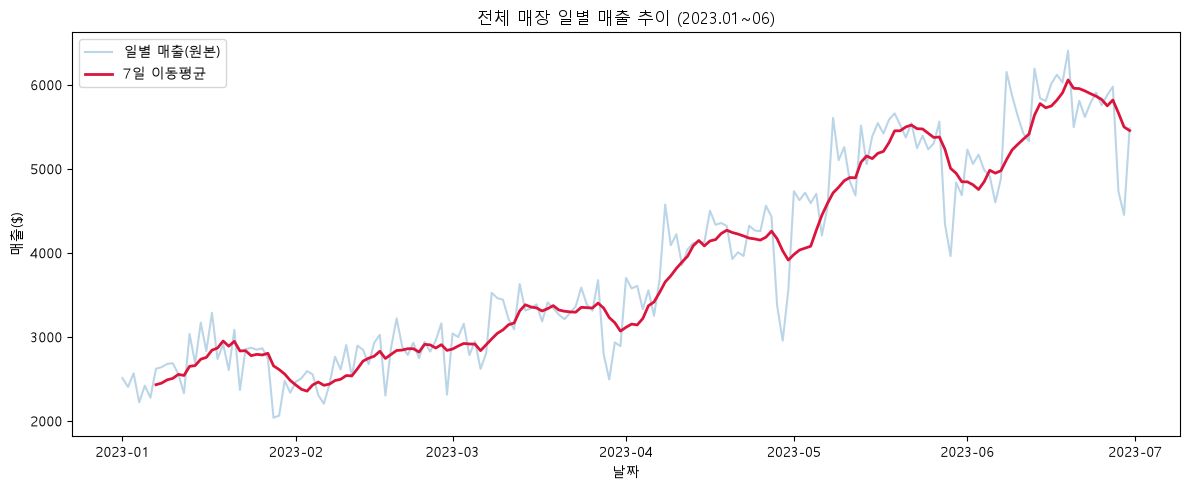

In [45]:
# 일별 매출 추이 확인 (7일 이동평균으로 요일별 노이즈 제거)
daily_sales = data.groupby('거래날짜')['매출'].sum()
daily_sales_ma7 = daily_sales.rolling(7).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values, alpha=0.3, label='일별 매출(원본)')
plt.plot(daily_sales_ma7.index, daily_sales_ma7.values, color='crimson', linewidth=2, label='7일 이동평균')
plt.title('전체 매장 일별 매출 추이 (2023.01~06)')
plt.ylabel('매출($)')
plt.xlabel('날짜')
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# 매장별 매출 성장을 '지수화'해서 비교 (1월 매출을 100으로 놓고 상대 비교)
# -> 특정 매장만 급성장하는 건 아닌지, 세 매장이 같은 속도로 크는지 확인
data['월'] = data['거래날짜'].dt.month
monthly_region = data.groupby(['카페지역', '월'])['매출'].sum().unstack()

jan_base = monthly_region[1]
index_region = monthly_region.div(jan_base, axis=0) * 100
index_region.round(1)

월,1,2,3,4,5,6
카페지역,,,,,,
Astoria,100.0,91.9,120.2,144.5,192.0,201.7
Hell's Kitchen,100.0,92.4,119.0,144.9,189.1,204.7
Lower Manhattan,100.0,95.4,123.9,147.5,194.8,205.1


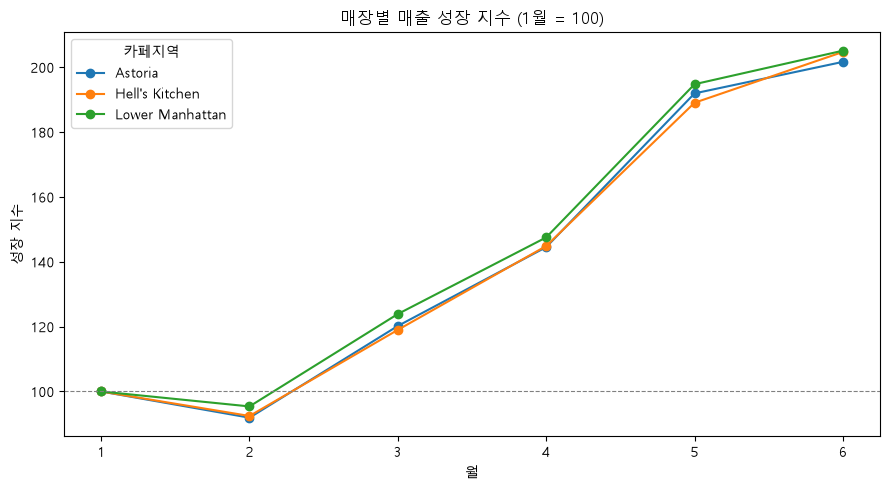

In [47]:
# 매장별 성장 지수 시각화
plt.figure(figsize=(9, 5))
for region in index_region.index:
    plt.plot(index_region.columns, index_region.loc[region], marker='o', label=region)

plt.axhline(100, color='gray', linestyle='--', linewidth=0.8)
plt.title('매장별 매출 성장 지수 (1월 = 100)')
plt.xlabel('월')
plt.ylabel('성장 지수')
plt.legend(title='카페지역')
plt.tight_layout()
plt.show()

### 성장의 원인 분해: 방문객수(트래픽) vs 객단가
> 매출 = 방문객수 × 객단가 이므로, 성장이 둘 중 어디서 왔는지 분해해본다.

In [48]:
# 같은 매장 + 같은 날짜 + 같은 시:분:초 = 한 번의 방문으로 재구성 (방문객수 파악용)
data['방문ID'] = data.groupby(['카페일련번호', '거래날짜', '거래시간']).ngroup()

visit_month = data.groupby('방문ID').agg(월=('월', 'first'), 매출=('매출', 'sum'))
monthly_visits = visit_month.groupby('월').agg(방문수=('매출', 'count'), 평균객단가=('매출', 'mean'))
monthly_visits.round(2)

,방문수,평균객단가
월,,
1,13575,6.02
2,12813,5.94
3,16606,5.95
4,19838,6.00
5,26248,5.97
6,27710,6.01


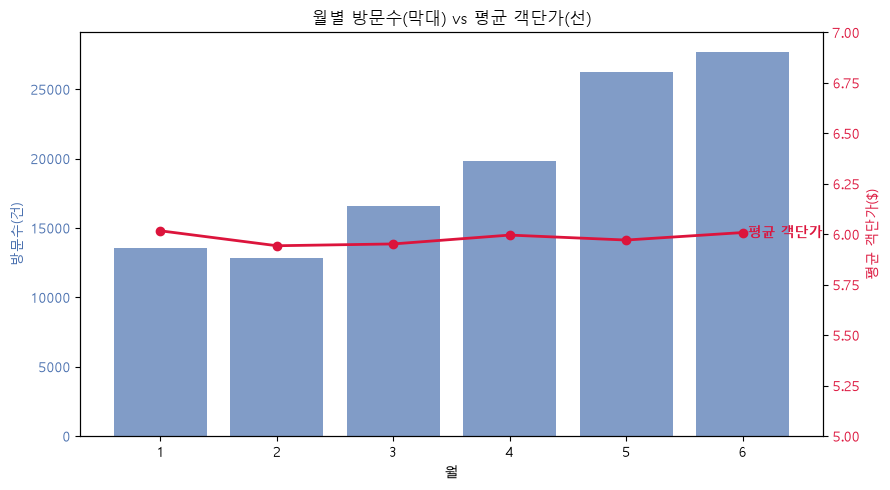

1월 대비 6월 방문수 성장률: 104.1 %
1월 대비 6월 객단가 성장률: -0.1 %


In [51]:
# 방문수(트래픽) vs 객단가 추이를 같이 시각화 (서로 다른 축 사용)
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(monthly_visits.index, monthly_visits['방문수'], color='#4C72B0', alpha=0.7, label='방문수')
ax1.set_xlabel('월')
ax1.set_ylabel('방문수(건)', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(monthly_visits.index, monthly_visits['평균객단가'], color='crimson', marker='o', linewidth=2, label='평균 객단가')
ax2.set_ylabel('평균 객단가($)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(5, 7)
# [추가] 마지막 데이터 포인트 옆에 텍스트 직접 표시하기
last_index = monthly_visits.index[-1]
last_value = monthly_visits['평균객단가'].iloc[-1]

# x축 위치를 마지막 index보다 아주 살짝 오른쪽으로 밀어서 글자가 겹치지 않게 합니다.
# (만약 index가 날짜 형태라면 형변환이나 조절이 필요할 수 있습니다)
ax2.text(last_index, last_value, ' 평균 객단가', 
         color='crimson', 
         va='center',          # 세로 기준 가운데 정렬
         ha='left',            # 가로 기준 왼쪽 정렬 (점의 오른쪽에 텍스트 위치)
         fontweight='bold')


plt.title('월별 방문수(막대) vs 평균 객단가(선)')
fig.tight_layout()
plt.show()

print('1월 대비 6월 방문수 성장률:', round((monthly_visits.loc[6,"방문수"]/monthly_visits.loc[1,"방문수"]-1)*100, 1), '%')
print('1월 대비 6월 객단가 성장률:', round((monthly_visits.loc[6,"평균객단가"]/monthly_visits.loc[1,"평균객단가"]-1)*100, 1), '%')

## 성장추세 분석 결과
> ### 분석 결과
> - 일평균 매출은 1월 약 2,635달러 → 6월 약 5,550달러로 **6개월간 110% 이상 성장**
> - 매장별 성장 지수(1월=100)가 6월 기준 Astoria 201.7, Hell's Kitchen 204.7, Lower Manhattan 205.1로 **매달 1~3포인트 차이밖에 나지 않을 만큼 세 매장이 거의 동일한 속도로 성장**
> - 성장의 원인을 분해하면, 방문수(트래픽)는 **+104.1%** 증가한 반면 평균 객단가는 **-0.1%**로 사실상 변화 없음
> - **가설 4는 채택** : 매출 성장은 '손님이 더 많이 왔기 때문'이며, '손님이 더 많이 썼기 때문'이 아니다. 이 성장은 특정 매장의 현상이 아니라 브랜드 전체에서 동시에 일어나는 공통 현상


## 분석결과 종합
#### 카테고리 구성비
> - Coffee, Tea 중심의 판매 구조는 세 지역 모두 동일 → 메뉴 포트폴리오는 공통 유지가 합리적

#### 시간대(피크타임) 패턴
> - 오전 피크(8~10시)는 공통이나, 저녁 시간대 이용 패턴은 지역별로 확연히 다름
> - Lower Manhattan = 오피스 상권형(출퇴근 집중, 저녁 영업 의미 낮음)
> - Astoria = 주거 상권형(저녁까지 꾸준한 수요)
> - Hell's Kitchen = 중간 성격의 혼합 상권

#### 객단가
> - 지역 간 차이는 존재하나(Lower Manhattan이 근소하게 높음) 폭이 작아 유의미한 전략 포인트로 보기는 어려움

#### 매출 성장추세
> - 6개월간 일평균 매출이 110% 이상 성장했고, 세 매장 모두 거의 동일한 속도로 성장
> - 성장의 원인은 객단가 상승(-0.1%)이 아니라 방문객수(트래픽) 증가(+104.1%)


## 인사이트 도출
#### 메뉴는 공통, 운영시간·인력은 지역 맞춤이 정답
>- 카테고리/상품 구성은 지역과 무관하게 이미 최적화되어 있어 메뉴 다양화보다 '운영 시간과 인력 배치' 쪽에 개선 여지가 큼

#### Lower Manhattan: 출퇴근 집중형 매장
>- 8~10시 오전 피크에 인력을 집중 배치하고, 19~20시는 영업시간 단축 또는 인력 최소화로 비용 절감 가능

#### Astoria: 종일 분산형 매장
>- 오전뿐 아니라 저녁까지 고르게 인력을 배치해야 하며, 저녁 시간대 프로모션(예: 애프터눈/이브닝 세트)의 효과가 상대적으로 클 것으로 기대

#### Hell's Kitchen: 혼합형 매장
>- 두 패턴의 중간 성격을 가지므로, 두 전략을 절충한 완만한 인력 배치가 적합

#### 성장은 '더 많은 손님'이 만들고 있다 → 확장에 대비한 준비가 필요
>- 매출 성장이 객단가가 아니라 순수 트래픽 증가에서 나온다는 것은, 지금의 인력·재고 체계가 늘어나는 손님 수를 감당할 수 있는지가 다음 병목이 될 수 있다는 뜻
>- 세 매장이 동일한 속도로 크고 있다는 건 특정 지점의 개별 노력이 아니라 브랜드 차원의 성장 동력(마케팅, 입소문, 계절 요인 등)일 가능성이 높음 → 원인 파악을 위한 후속 조사(마케팅 캠페인 이력, 날씨 데이터 등과의 대조) 필요
>- 이 추세가 유지된다면 여름 성수기(7~8월) 진입 전에 재고·인력 확충 계획을 선제적으로 세워야 함


## 페르소나
- 우리 서비스(분석 결과 기반 매장 운영 대시보드)를 사용할 핵심 사용자

### 1. 기본 정보
- **이름**: 김운영
- **나이**: 34
- **성별**: 여

### 2. 배경 및 상황
- **직무**: 카페 체인 3개 지점을 총괄하는 지역 운영 매니저
- **현재 상태**: 본사 지침에 따라 3개 매장을 동일한 방식으로 운영 중이며, 최근 매출이 꾸준히 느는 걸 체감하고 있으나 정확한 원인은 파악하지 못함

### 3. 문제 인식 및 고민
- **현재 느끼는 고민**: "왜 같은 메뉴, 같은 시스템인데 매장마다 저녁 매출 편차가 큰지 감으로만 파악하고 있다", "매출이 느는 건 좋은데, 이게 계속될지 몰라서 인력·재고를 얼마나 더 준비해야 할지 감이 안 잡힌다"
- **기존에 겪은 불만족스러운 경험**: 저녁 시간대에 Lower Manhattan 매장에 정직원을 그대로 배치해 인건비 대비 매출 효율이 떨어졌던 경험, 갑자기 손님이 몰리는 날 재고가 부족했던 경험

### 4. 동기와 목표

- **단기 목표 (1~3개월)**:
  매장별 피크타임·객단가 데이터를 근거로 시간대별 인력 배치를 재설계하고, 상권 유형(오피스형/주거형)에 안 맞는 저녁 운영 방식을 개선

- **장기 목표 (6개월~1년)**:
  방문객수·객단가 추이를 상시 모니터링하는 체계를 구축해, 지금의 성장 추세가 꺾이거나 급등하기 전에 인력·재고·신규 매장 계획을 선제적으로 대응


## 솔루션 도출 – RegionFit

### 🎯 목표
지역(상권) 특성에 따라 매장별 운영 전략(영업시간, 인력배치)을 데이터 기반으로 자동 제안하고,
전체 성장 추세를 모니터링해 확장에 선제적으로 대비하는 솔루션

### 📌 솔루션명
**RegionFit** — 상권 유형 진단 + 성장추세 모니터링 기반 매장 운영 최적화 대시보드

### 🔧 주요 기능 구성

| 기능 구분 | 기능 설명 | 기대 효과 |
|-----------|-----------|------------|
| **1. 상권 유형 자동 분류** | 시간대별 매출 분포를 기준으로 매장을 '오피스형/주거형/혼합형'으로 자동 분류 | 신규 매장도 데이터만 쌓이면 빠르게 상권 유형 파악 |
| **2. 시간대별 인력배치 추천** | 상권 유형별 피크타임에 맞춰 시간대별 권장 인력 수 제안 | 인건비 대비 매출 효율 개선 |
| **3. 저녁 프로모션 타겟팅** | 주거형 매장에 한해 저녁 시간대 프로모션 효과 시뮬레이션 제공 | 상권 특성에 안 맞는 프로모션 비용 낭비 방지 |
| **4. 성장추세 트래킹 & 조기경보** | 방문객수·객단가를 매달 분해 추적하고, 성장률이 꺾이거나 급등할 때 알림 | 인력·재고 확충 시점을 감이 아닌 데이터로 결정 |
| **5. 매장 간 비교 리포트** | 카테고리 구성비/객단가는 공통 지표로, 시간대 패턴·성장 지수는 차별 지표로 시각화 | 본사-지점 간 공통 논의 기반 마련 |


# 4. 솔루션 구현 – 성장추세 트래킹 & 조기경보

가설 4 검증에서 확인했듯, 매출 성장은 객단가가 아니라 **방문객수(트래픽) 증가**에서 나오고 있다.
RegionFit의 4번 기능(성장추세 트래킹 & 조기경보)을 실제로 구현해,
- 지역별로 매달 방문수/객단가가 전월 대비 얼마나 변했는지 계산하고
- 변화율이 정상 범위를 벗어나면(급감 또는 급증) 자동으로 경보를 띄우는

간단한 모니터링 로직을 만들어본다.

In [52]:
# 지역별 + 방문(방문ID) 단위로 매출 집계 (방문ID는 앞서 카페일련번호+날짜+시간으로 생성한 고유 방문 단위)
visit_region_month = data.groupby(['카페지역', '방문ID']).agg(
    월=('월', 'first'),
    매출=('매출', 'sum')
).reset_index()

# 지역-월 단위로 방문수 / 매출합계 / 평균객단가 집계
monthly_region_trend = visit_region_month.groupby(['카페지역', '월']).agg(
    방문수=('매출', 'count'),
    매출합계=('매출', 'sum'),
    평균객단가=('매출', 'mean')
).reset_index().sort_values(['카페지역', '월'])

# 전월 대비 증감률(%) 계산 (지역별로 따로 계산)
monthly_region_trend['방문수_MoM(%)'] = monthly_region_trend.groupby('카페지역')['방문수'].pct_change() * 100
monthly_region_trend['객단가_MoM(%)'] = monthly_region_trend.groupby('카페지역')['평균객단가'].pct_change() * 100

monthly_region_trend.round(2)

,카페지역,월,방문수,매출합계,평균객단가,방문수_MoM(%),객단가_MoM(%)
0,Astoria,1,4747,27313.66,5.75,NaN,NaN
1,Astoria,2,4398,25105.34,5.71,-7.35,-0.79
2,Astoria,3,5755,32835.43,5.71,30.85,-0.05
3,Astoria,4,6895,39477.61,5.73,19.81,0.35
4,Astoria,5,9226,52428.76,5.68,33.81,-0.75
5,Astoria,6,9663,55083.11,5.70,4.74,0.31
6,Hell's Kitchen,1,4721,27820.65,5.89,NaN,NaN
7,Hell's Kitchen,2,4494,25719.80,5.72,-4.81,-2.88
8,Hell's Kitchen,3,5769,33110.57,5.74,28.37,0.28
9,Hell's Kitchen,4,6880,40304.14,5.86,19.26,2.07


In [53]:
# 조기경보 로직: 전월 대비 방문수 증감률이 정상 범위(drop_th ~ surge_th)를 벗어나면 경보 라벨 부여
# - 급감(drop_th 이하): 인력 과잉/재고 과다 리스크 -> 운영 축소 검토 신호
# - 급증(surge_th 이상): 인력 부족/재고 부족 리스크 -> 선제적 확충 검토 신호
def label_alert(pct, drop_th=-10, surge_th=30):
    if pd.isna(pct):
        return '-'
    elif pct <= drop_th:
        return '⚠️ 급감 경보'
    elif pct >= surge_th:
        return '🚨 급증 경보'
    else:
        return '정상'

monthly_region_trend['방문수_경보'] = monthly_region_trend['방문수_MoM(%)'].apply(label_alert)

# 경보가 발생한 지역-월만 추출해서 확인
alerts = monthly_region_trend[monthly_region_trend['방문수_경보'] != '정상']
alerts[['카페지역', '월', '방문수', '방문수_MoM(%)', '방문수_경보']].round(2)

,카페지역,월,방문수,방문수_MoM(%),방문수_경보
0,Astoria,1,4747,NaN,-
2,Astoria,3,5755,30.85,🚨 급증 경보
4,Astoria,5,9226,33.81,🚨 급증 경보
6,Hell's Kitchen,1,4721,NaN,-
10,Hell's Kitchen,5,8980,30.52,🚨 급증 경보
12,Lower Manhattan,1,4107,NaN,-
16,Lower Manhattan,5,8042,32.64,🚨 급증 경보


C:\Users\smhrd\AppData\Local\Temp\ipykernel_23976\4234317782.py:23: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\smhrd\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


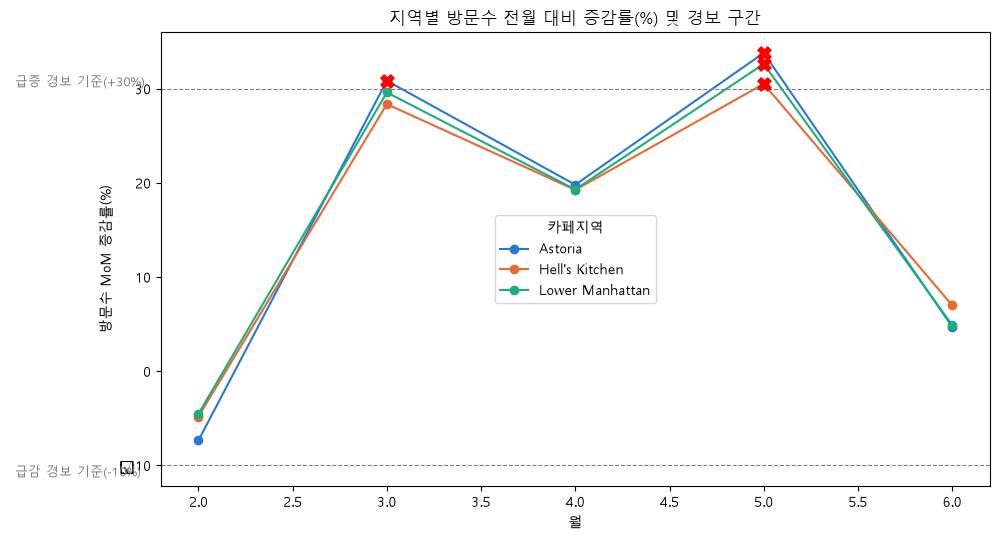

In [54]:
# 지역별 방문수 MoM 증감률 추이 + 경보 구간 시각화
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = {'Astoria': '#2a78d6', "Hell's Kitchen": '#eb6834', 'Lower Manhattan': '#1baf7a'}

for region in monthly_region_trend['카페지역'].unique():
    sub = monthly_region_trend[monthly_region_trend['카페지역'] == region]
    ax.plot(sub['월'], sub['방문수_MoM(%)'], marker='o', label=region, color=colors.get(region))

    # 경보(급감/급증)가 발생한 지점만 강조 표시
    alert_points = sub[sub['방문수_경보'] != '정상']
    ax.scatter(alert_points['월'], alert_points['방문수_MoM(%)'], color='red', zorder=5, s=90,
               marker='X', label='_nolegend_')

ax.axhline(30, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(-10, color='gray', linestyle='--', linewidth=0.8)
ax.text(1, 30, ' 급증 경보 기준(+30%)', va='bottom', fontsize=9, color='gray')
ax.text(1, -10, ' 급감 경보 기준(-10%)', va='top', fontsize=9, color='gray')

ax.set_title('지역별 방문수 전월 대비 증감률(%) 및 경보 구간')
ax.set_xlabel('월')
ax.set_ylabel('방문수 MoM 증감률(%)')
ax.legend(title='카페지역')
plt.tight_layout()
plt.show()

In [55]:
# 실제 운영에서 "매달 이 함수를 돌린다"고 가정한 조기경보 체크 함수
# -> 최신 월 기준으로 지역별 경보 상태를 문장으로 요약해서 알려준다
def check_latest_alert(trend_df, target_month=None):
    month = target_month or trend_df['월'].max()
    latest = trend_df[trend_df['월'] == month]

    print(f'=== {month}월 방문수 조기경보 체크 ===')
    for _, row in latest.iterrows():
        region, pct, status = row['카페지역'], row['방문수_MoM(%)'], row['방문수_경보']
        if status == '정상':
            print(f'- {region}: 전월 대비 {pct:+.1f}% (정상 범위)')
        elif status == '⚠️ 급감 경보':
            print(f'- {region}: 전월 대비 {pct:+.1f}% -> ⚠️ 급감! 인력·재고 축소 검토 필요')
        else:
            print(f'- {region}: 전월 대비 {pct:+.1f}% -> 🚨 급증! 인력·재고 확충 검토 필요')

# 최신월(6월) 기준으로 조기경보 실행 예시
check_latest_alert(monthly_region_trend)

=== 6월 방문수 조기경보 체크 ===
- Astoria: 전월 대비 +4.7% (정상 범위)
- Hell's Kitchen: 전월 대비 +7.0% (정상 범위)
- Lower Manhattan: 전월 대비 +4.9% (정상 범위)
